# SafeHer: Predicting Women Safety Across Districts of Uttar Pradesh

### Problem Statement
#### Ensuring the safety of women remains a critical concern, especially in densely populated regions like Uttar Pradesh. This project aims to analyze historical crime data related to women across different districts and identify patterns affecting safety.
#### Using data-driven techniques, the project seeks to develop a predictive model that can estimate safety levels based on various crime indicators. The goal is to provide insights into high-risk areas and highlight key factors influencing women’s safety, enabling better awareness and decision-making.

### Dataset Description
#### The dataset contains crime records related to women across various districts in India over multiple years (2001–2014). For this project, the data has been filtered specifically for Uttar Pradesh to maintain focus and consistency.
#### It includes district-wise information on different types of crimes against women, which are used as indicators to assess safety levels.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [22]:
df = pd.read_csv(r"C:\Users\WELCOME\Downloads\archive\crimes_against_women_2001-2014.csv")

In [23]:
df.head()

,index,STATE_UT,DISTRICT,Year,Rape,Kidnapping_Abduction,Dowry_Deaths,Assault_to_outrage_her_modesty,Insult_to_modesty_of_Women,Cruelty_by_Husband_or_his_Relatives,Importation_Girls
0,0,ANDHRA PRADESH,ADILABAD,2001,50,30,16,149,34,175,0
1,1,ANDHRA PRADESH,ANANTAPUR,2001,23,30,7,118,24,154,0
2,2,ANDHRA PRADESH,CHITTOOR,2001,27,34,14,112,83,186,0
3,3,ANDHRA PRADESH,CUDDAPAH,2001,20,20,17,126,38,57,0
4,4,ANDHRA PRADESH,EAST GODAVARI,2001,23,26,12,109,58,247,0


## Data Filtering

In [24]:
df['STATE_UT'] = df['STATE_UT'].str.strip().str.lower()
df_up = df[df['STATE_UT']== 'uttar pradesh']
df_up.head()

,index,STATE_UT,DISTRICT,Year,Rape,Kidnapping_Abduction,Dowry_Deaths,Assault_to_outrage_her_modesty,Insult_to_modesty_of_Women,Cruelty_by_Husband_or_his_Relatives,Importation_Girls
579,579,uttar pradesh,AGRA,2001,66,132,63,110,114,327,0
580,580,uttar pradesh,ALIGARH,2001,50,78,44,90,54,258,0
581,581,uttar pradesh,ALLAHABAD,2001,42,75,56,85,105,226,0
582,582,uttar pradesh,AMBEDKAR NAGAR,2001,19,29,14,15,9,87,0
583,583,uttar pradesh,AURAIYA,2001,11,25,21,13,7,26,0


## Data Cleaning and Preprocessing

In [25]:
df_up = df_up.drop(columns = ['index', 'STATE_UT'])

In [26]:
df_up = df_up.rename(columns = {'DISTRICT' :'district'})

In [27]:
df_up.head()

,district,Year,Rape,Kidnapping_Abduction,Dowry_Deaths,Assault_to_outrage_her_modesty,Insult_to_modesty_of_Women,Cruelty_by_Husband_or_his_Relatives,Importation_Girls
579,AGRA,2001,66,132,63,110,114,327,0
580,ALIGARH,2001,50,78,44,90,54,258,0
581,ALLAHABAD,2001,42,75,56,85,105,226,0
582,AMBEDKAR NAGAR,2001,19,29,14,15,9,87,0
583,AURAIYA,2001,11,25,21,13,7,26,0


In [28]:
df_up.shape

(1032, 9)

In [29]:
df_up.isnull().sum()

district                               0
Year                                   0
Rape                                   0
Kidnapping_Abduction                   0
Dowry_Deaths                           0
Assault_to_outrage_her_modesty         0
Insult_to_modesty_of_Women             0
Cruelty_by_Husband_or_his_Relatives    0
Importation_Girls                      0
dtype: int64

In [30]:
df_up.dtypes

district                               object
Year                                    int64
Rape                                    int64
Kidnapping_Abduction                    int64
Dowry_Deaths                            int64
Assault_to_outrage_her_modesty          int64
Insult_to_modesty_of_Women              int64
Cruelty_by_Husband_or_his_Relatives     int64
Importation_Girls                       int64
dtype: object

In [31]:
df_up.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1032 entries, 579 to 10595
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   district                             1032 non-null   object
 1   Year                                 1032 non-null   int64 
 2   Rape                                 1032 non-null   int64 
 3   Kidnapping_Abduction                 1032 non-null   int64 
 4   Dowry_Deaths                         1032 non-null   int64 
 5   Assault_to_outrage_her_modesty       1032 non-null   int64 
 6   Insult_to_modesty_of_Women           1032 non-null   int64 
 7   Cruelty_by_Husband_or_his_Relatives  1032 non-null   int64 
 8   Importation_Girls                    1032 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 80.6+ KB


In [32]:
df_up = df_up.reset_index(drop= True)

 The dataset originally contained data for multiple states across different years. After filtering for Uttar Pradesh, the index values were non-sequential as they retained their original positions. Therefore, the index was reset to maintain a clean and consistent structure.

## Checking Inconsistencies

In [33]:
df_up['district'].str.contains(r'\d', regex = True).sum()

np.int64(0)

No numerical inconsistencies found in the district column.

In [34]:
for col in df_up.select_dtypes(include = ['int64']):
    invalid = df_up[df_up[col].notna() & pd.to_numeric(df_up[col], errors = 'coerce').isna()]
    if len(invalid) > 0:
        print(f"{col} has invalid values")

In [35]:
df_up['district'].nunique()

162

The dataset contains more district entries than the officially recognized number. This discrepancy may be due to variations in naming, administrative changes over time, or duplicate entries. Let's do Basic cleaning and standardization to improve consistency.

In [36]:
sorted(df_up['district'].unique())

['AGRA',
 'ALIGARH',
 'ALLAHABAD',
 'AMBEDKAR NAGAR',
 'AMETHI',
 'AMROHA',
 'AURAIYA',
 'AZAMGARH',
 'Agra',
 'Aligarh',
 'Allahabad',
 'Ambedkar Nagar',
 'Amethi',
 'Amroha',
 'Auraiya',
 'Azamgarh',
 'BADAUN',
 'BAGHPAT',
 'BAHRAICH',
 'BALLIA',
 'BALRAMPUR',
 'BANDA',
 'BARABANKI',
 'BAREILLY',
 'BASTI',
 'BHIM NAGAR',
 'BIJNOR',
 'BULANDSHAHAR',
 'Badaun',
 'Baghpat',
 'Bahraich',
 'Ballia',
 'Balrampur',
 'Banda',
 'Barabanki',
 'Bareilly',
 'Basti',
 'Bhadohi',
 'Bijnor',
 'Bulandshahar',
 'CHANDOLI',
 'CHITRAKOOT DHAM',
 'CSM NAGAR',
 'Chandoli',
 'Chitrakoot',
 'DEORIA',
 'Deoria',
 'ETAH',
 'ETAWAH',
 'Etah',
 'Etawah',
 'FAIZABAD',
 'FATEHGARH',
 'FATEHPUR',
 'FIROZABAD',
 'Faizabad',
 'Fatehgarh',
 'Fatehpur',
 'Firozabad',
 'G. R. P.',
 'G.R.P.',
 'GAUTAMBUDH NAGAR',
 'GHAZIABAD',
 'GHAZIPUR',
 'GONDA',
 'GORAKHPUR',
 'Gautambudh Nagar',
 'Ghaziabad',
 'Ghazipur',
 'Gonda',
 'Gorakhpur',
 'HAMIRPUR',
 'HAPUR',
 'HARDOI',
 'HATHRAS',
 'Hamirpur',
 'Hapur',
 'Hardoi',
 'Hath

In [37]:
df_up['district'] = df_up['district'].str.strip().str.title()

In [38]:
invalid_districts = ['G. R. P.', 'G.R.P.', 'Total', 'Total District(S)', 'Zz Total']
df_up = df_up[~df_up['district'].isin(invalid_districts)]

Certain non-district entries such as aggregated totals and administrative categories (e.g., G.R.P.) were present in the dataset. These were removed to ensure that only valid district-level data is used for analysis.

In [39]:
df_up.shape

(1004, 9)

A small number of rows containing non-district entries were removed during preprocessing. This resulted in a minimal reduction in dataset size, ensuring that the majority of valid data was retained.

# Explorartory Data Analysis(EDA)

## Basic overview

In [40]:
df_up.describe()

,Year,Rape,Kidnapping_Abduction,Dowry_Deaths,Assault_to_outrage_her_modesty,Insult_to_modesty_of_Women,Cruelty_by_Husband_or_his_Relatives,Importation_Girls
count,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000
mean,2007.606574,25.441235,67.590637,28.499004,45.060757,26.128486,96.481076,0.002988
std,4.050233,19.731284,67.287561,16.985625,47.751489,45.939169,115.073727,0.094679
min,2001.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,11.000000,22.000000,16.000000,16.000000,0.000000,26.000000,0.000000
50%,2008.000000,20.000000,46.500000,25.000000,31.000000,10.000000,59.000000,0.000000
75%,2011.000000,34.000000,90.000000,37.000000,55.000000,32.250000,119.000000,0.000000
max,2014.000000,118.000000,413.000000,98.000000,412.000000,578.000000,1083.000000,3.000000


## Total crime feature

In [41]:
crime_cols = ['Rape','Kidnapping_Abduction' ,'Dowry_Deaths','Assault_to_outrage_her_modesty','Insult_to_modesty_of_Women','Cruelty_by_Husband_or_his_Relatives','Importation_Girls']
df_up['total_crime'] = df_up[crime_cols].sum(axis=1)

In [42]:
df_up.head()

,district,Year,Rape,Kidnapping_Abduction,Dowry_Deaths,Assault_to_outrage_her_modesty,Insult_to_modesty_of_Women,Cruelty_by_Husband_or_his_Relatives,Importation_Girls,total_crime
0,Agra,2001,66,132,63,110,114,327,0,812
1,Aligarh,2001,50,78,44,90,54,258,0,574
2,Allahabad,2001,42,75,56,85,105,226,0,589
3,Ambedkar Nagar,2001,19,29,14,15,9,87,0,173
4,Auraiya,2001,11,25,21,13,7,26,0,103


In [43]:
df_up.to_csv('up_women_crime.csv', index = False)

# Statistical Analysis:

## Top 10 affected Districts

In [44]:
top_districts = df_up.groupby('district')['total_crime'].sum().sort_values(ascending=False).head(10)
print(top_districts)

district
Lucknow         16436
Kanpur Nagar    13018
Agra            11827
Meerut          10515
Aligarh          9671
Ghaziabad        9522
Bareilly         8786
Moradabad        8402
Allahabad        7811
Bulandshahar     7435
Name: total_crime, dtype: int64


## Least Affected Districts

In [45]:
df_up.groupby('district')['total_crime'].sum().sort_values(ascending=False).tail(10)

district
St.Ravidasnagar    606
Amethi             553
Shamli             523
Hapur              517
Bhim Nagar         507
Kasganj            423
Panchshil Nagar    369
Prabuddh Nagar     319
Chitrakoot         148
Bhadohi            128
Name: total_crime, dtype: int64

Luknow is the most most affected district and Bhadohi is the safest district.

## Total Crimes per Category

In [46]:
ctd = df_up[['Rape','Kidnapping_Abduction','Dowry_Deaths','Assault_to_outrage_her_modesty','Insult_to_modesty_of_Women','Cruelty_by_Husband_or_his_Relatives','Importation_Girls']].sum().sort_values(ascending = False)
print(ctd)

Cruelty_by_Husband_or_his_Relatives    96867
Kidnapping_Abduction                   67861
Assault_to_outrage_her_modesty         45241
Dowry_Deaths                           28613
Insult_to_modesty_of_Women             26233
Rape                                   25543
Importation_Girls                          3
dtype: int64


## Year-wise Trend

In [47]:
yearly_crime = df_up.groupby('Year')['total_crime'].sum()
print(yearly_crime)

Year
2001    19763
2002    15269
2003    12392
2004    14907
2005    14212
2006    15631
2007    20099
2008    23122
2009    22872
2010    20000
2011    22421
2012    22985
2013    31112
2014    35576
Name: total_crime, dtype: int64


# Visualizations:

## Crime Type Comparission

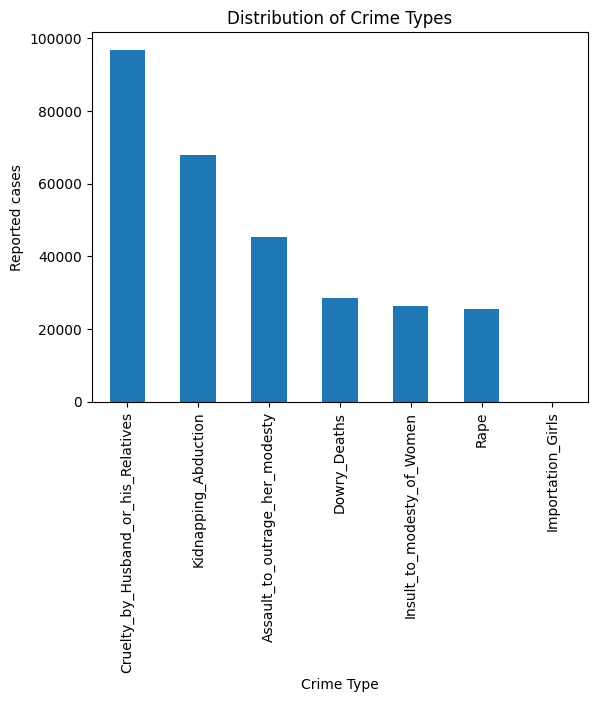

In [48]:
ctd.plot(kind = 'bar')
plt.title("Distribution of Crime Types")
plt.xlabel('Crime Type')
plt.ylabel('Reported cases')
plt.show()

## Top 10 Most Affected Districts

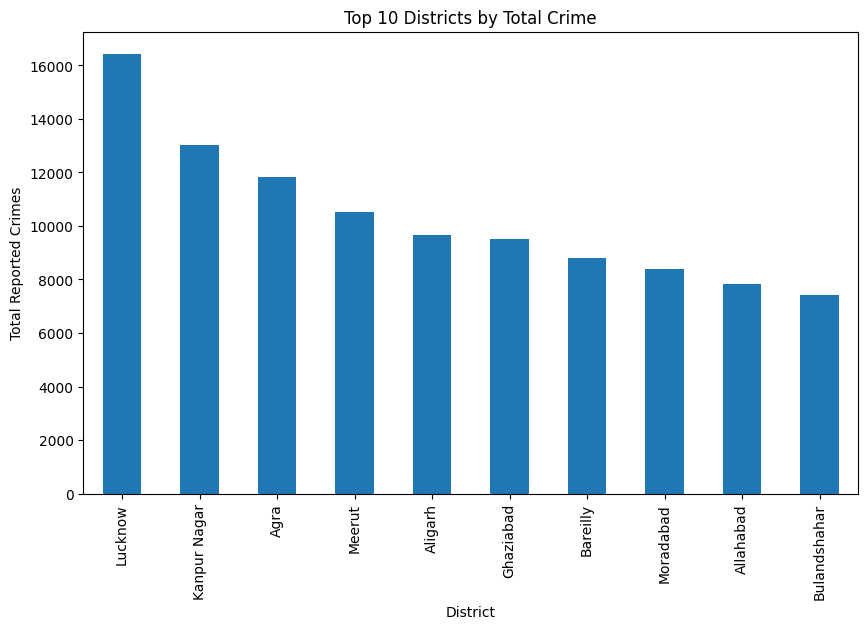

In [49]:
top = df_up.groupby('district')['total_crime'].sum().sort_values(ascending = False).head(10)
plt.figure(figsize = (10,6))
top.plot(kind = 'bar')
plt.title("Top 10 Districts by Total Crime")
plt.xlabel("District")
plt.ylabel("Total Reported Crimes")
plt.show()

## Trend over Years

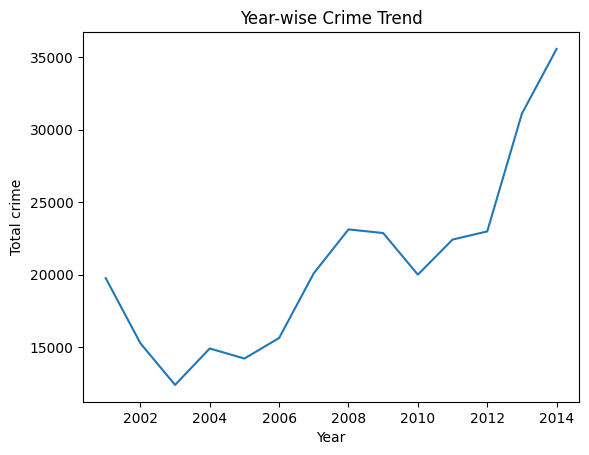

<Figure size 800x500 with 0 Axes>

In [50]:
yearly_crime.plot(kind = 'line')
plt.title("Year-wise Crime Trend")
plt.xlabel("Year")
plt.ylabel("Total crime")
plt.figure(figsize = (8,5))
plt.show()

### Observation :
 The overall trend shows a gradual increase in reported crimes against women over the years in Uttar Pradesh. After minor fluctuations during early years , crime rate sharply increased after 2011, reaching their peak around 2014.

## Year over Year Percentage Change

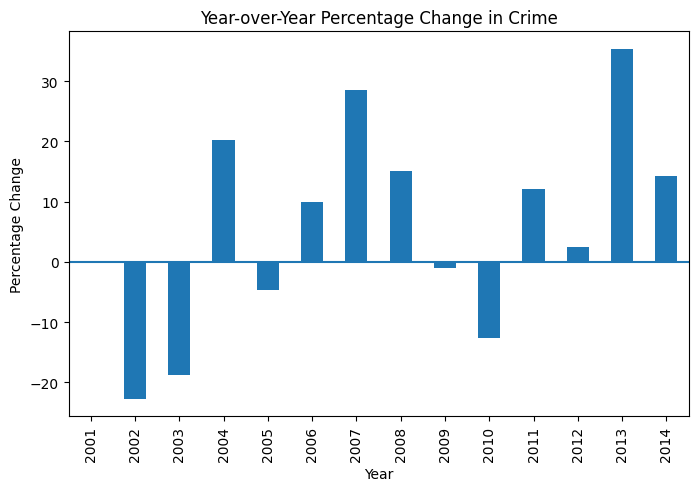

In [52]:
yoy_change = yearly_crime.pct_change()*100
plt.figure(figsize=(8,5))
yoy_change.plot(kind = 'bar')
plt.title("Year-over-Year Percentage Change in Crime")
plt.xlabel("Year")
plt.ylabel("Percentage Change")
plt.axhline(0)
plt.show()

### Observation:
Crime reporting showed fluctuating year-over-year growth, with significant spikes observed in 2007 and 2013, indicating periods of rapid increase in reported crimes against women.

## Correlation Between Crime Types

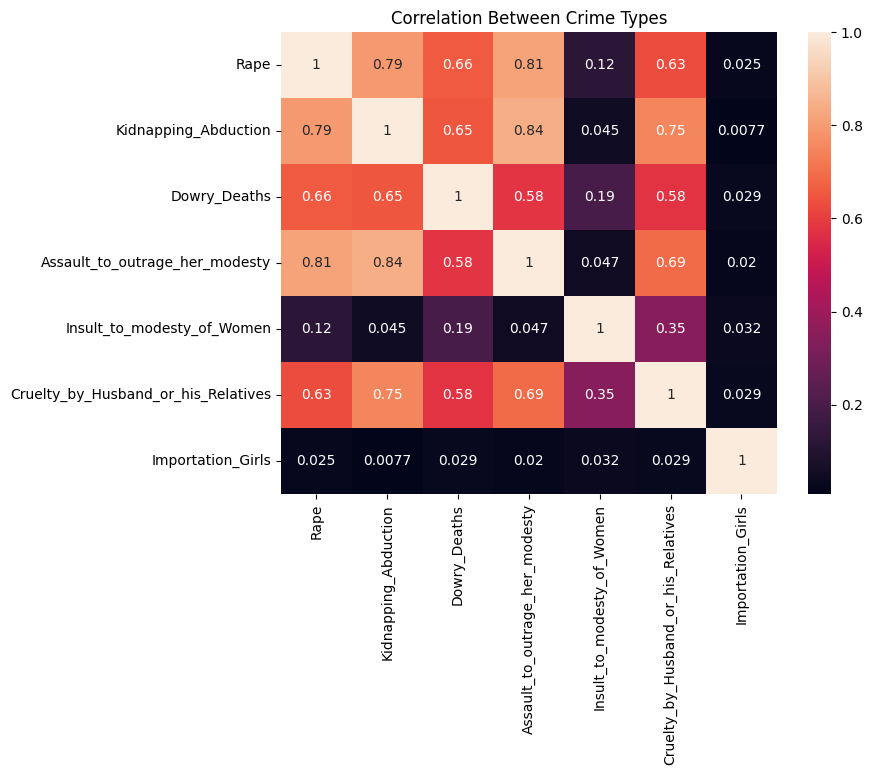

In [54]:
corr_matrix = df_up[['Rape','Kidnapping_Abduction','Dowry_Deaths','Assault_to_outrage_her_modesty','Insult_to_modesty_of_Women','Cruelty_by_Husband_or_his_Relatives','Importation_Girls']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Between Crime Types")
plt.show()

#### Observation:
Strong positive correlations are observed between kidnapping, rape, and assault-related crimes, suggesting that these crime categories often increase togrther across districts and years. In contrast, the importation of girls showed very weak correlation with other crime types, indicating a distinct reporting patter.

## District Heatmap

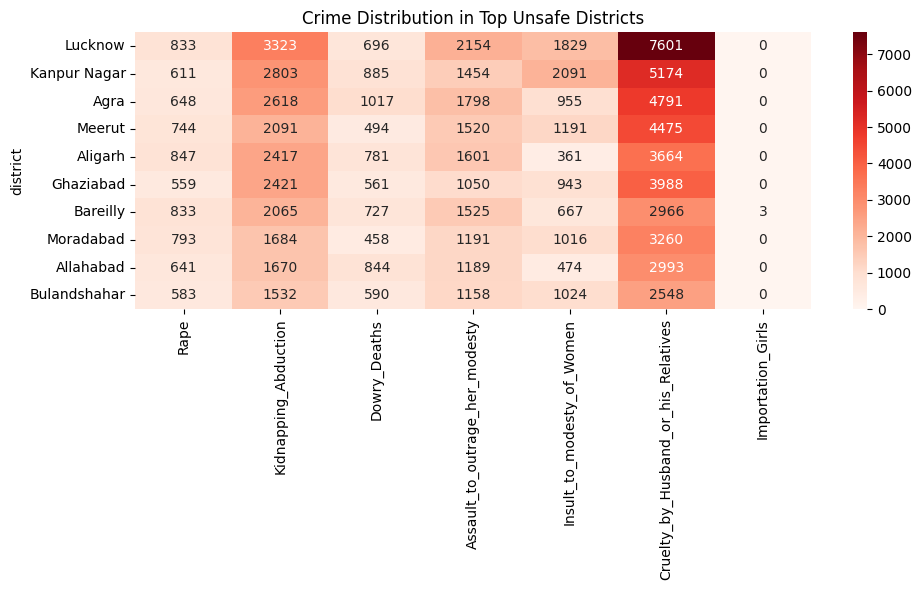

In [55]:
district_crime = df_up.groupby('district')[['Rape','Kidnapping_Abduction' ,'Dowry_Deaths','Assault_to_outrage_her_modesty','Insult_to_modesty_of_Women','Cruelty_by_Husband_or_his_Relatives','Importation_Girls']].sum()
district_crime['total'] = district_crime.sum(axis = 1)
top10 = district_crime.sort_values(by = 'total', ascending = False).head(10)
top10 = top10.drop('total', axis = 1)
plt.figure(figsize = (10,6))
sns.heatmap(top10, annot = True, fmt = '.0f', cmap = 'Reds')
plt.title("Crime Distribution in Top Unsafe Districts")
plt.tight_layout()
plt.show()